# QM640 Food Price Affordability AI
## Notebook 07 — Multi-Horizon Explainability

This notebook explains the selected continuous price models and shock
classifiers without presenting predictive importance as causal attribution.
Global permutation importance is calculated on chronological holdouts, and
local one-standard-deviation sensitivity is reported for the highest forward
risk observation.


## 1. Setup and verified upstream evidence


In [1]:
from pathlib import Path
import json, os, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
pd.set_option("display.width", 190)

try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_ROOT = Path("/content/drive/MyDrive/QM640_Food_Affordability")
else:
    root = Path.cwd().resolve()
    if root.name == "notebooks": root = root.parent
    OUTPUT_ROOT = Path(os.environ.get("QM640_OUTPUT_ROOT", str(root)))

PROCESSED = OUTPUT_ROOT / "data" / "processed"
REPORT_OUTPUT = OUTPUT_ROOT / "reports" / "notebook_outputs"
FIGURES = REPORT_OUTPUT / "figures"
REPORT_OUTPUT.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
SKIP_PLOTS = os.environ.get("QM640_SKIP_PLOTS", "0") == "1"

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
if not SKIP_PLOTS:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style="whitegrid")

state = pd.read_csv(PROCESSED / "cleaned_state_monthly.csv.gz", parse_dates=["date"], low_memory=False)
nb05 = json.loads((REPORT_OUTPUT / "05_execution_summary.json").read_text(encoding="utf-8"))
nb06 = json.loads((REPORT_OUTPUT / "06_execution_summary.json").read_text(encoding="utf-8"))
forward_risk = pd.read_csv(REPORT_OUTPUT / "06_forward_multihorizon_shock_risk.csv", parse_dates=["feature_date", "target_date"])
print("Forecast winners:", nb05["selected_models_by_horizon"])
print("Shock winners:", nb06["selected_models"])


Mounted at /content/drive
Forecast winners: {'1_month': 'hist_gradient_boosting', '2_month': 'hist_gradient_boosting', '3_month': 'hist_gradient_boosting'}
Shock winners: {'1_month': 'hist_gradient_boosting', '2_month': 'hist_gradient_boosting', '3_month': 'hist_gradient_boosting'}


## 2. Refit selected models on chronological train/holdout samples


In [2]:
TARGETS = {1: "future_price_change_h1m_pct", 2: "future_price_change_h2m_pct", 3: "future_price_change_h3m_pct"}
numeric_features = [
    "price_mom_pct", "price_yoy_pct", "rainfall_anomaly_pct",
    "temperature_anomaly_c", "relative_humidity_pct",
    "production_tonne", "yield_kg_per_hectare",
    "rural_wage_rs_per_day", "source_rows",
]
numeric_features = [c for c in numeric_features if c in state.columns]
categorical_features = ["region", "Commodity", "month"]
feature_columns = numeric_features + categorical_features
data = state.copy()
data["month"] = data["date"].dt.month.astype(str)

def preprocessor():
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features),
    ])

def regression_model():
    return Pipeline([
        ("prep", preprocessor()),
        ("model", HistGradientBoostingRegressor(
            learning_rate=0.05, max_iter=160, max_leaf_nodes=20,
            min_samples_leaf=30, l2_regularization=1.0, random_state=640
        )),
    ])

def shock_model():
    return Pipeline([
        ("prep", preprocessor()),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.05, max_iter=160, max_leaf_nodes=20,
            min_samples_leaf=30, l2_regularization=1.0, random_state=640
        )),
    ])


## 3. Out-of-sample permutation importance


In [3]:
forecast_importance_rows, shock_importance_rows = [], []
fitted_shock_models = {}
for horizon, target in TARGETS.items():
    last_usable = data.loc[data[target].notna(), "date"].max()
    holdout_start = last_usable - pd.DateOffset(months=11)
    train = data.loc[data["date"].lt(holdout_start) & data[target].notna()].copy()
    test = data.loc[data["date"].between(holdout_start, last_usable) & data[target].notna()].copy()

    reg = regression_model()
    reg.fit(train[feature_columns], train[target])
    reg_pi = permutation_importance(
        reg, test[feature_columns], test[target], scoring="neg_root_mean_squared_error",
        n_repeats=8, random_state=640, n_jobs=-1
    )
    for feature, mean, sd in zip(feature_columns, reg_pi.importances_mean, reg_pi.importances_std):
        forecast_importance_rows.append({
            "horizon_months": horizon, "feature": feature,
            "rmse_increase_mean": float(mean), "rmse_increase_sd": float(sd),
            "holdout_start": holdout_start, "holdout_end": last_usable,
            "holdout_rows": int(len(test)),
        })

    thresholds = train.groupby("Commodity", observed=True)[target].quantile(0.90)
    train = train.join(thresholds.rename("threshold"), on="Commodity")
    test = test.join(thresholds.rename("threshold"), on="Commodity")
    train["shock"] = train[target].ge(train["threshold"]).astype(int)
    test["shock"] = test[target].ge(test["threshold"]).astype(int)
    clf = shock_model()
    prevalence = train["shock"].mean()
    weights = np.where(train["shock"].eq(1), 0.5 / prevalence, 0.5 / (1 - prevalence))
    clf.fit(train[feature_columns], train["shock"], model__sample_weight=weights)
    fitted_shock_models[horizon] = clf
    clf_pi = permutation_importance(
        clf, test[feature_columns], test["shock"], scoring="average_precision",
        n_repeats=8, random_state=640, n_jobs=-1
    )
    for feature, mean, sd in zip(feature_columns, clf_pi.importances_mean, clf_pi.importances_std):
        shock_importance_rows.append({
            "horizon_months": horizon, "feature": feature,
            "average_precision_decrease_mean": float(mean),
            "average_precision_decrease_sd": float(sd),
            "holdout_rows": int(len(test)),
            "holdout_shocks": int(test["shock"].sum()),
        })

forecast_importance = pd.DataFrame(forecast_importance_rows).sort_values(
    ["horizon_months", "rmse_increase_mean"], ascending=[True, False]
)
shock_importance = pd.DataFrame(shock_importance_rows).sort_values(
    ["horizon_months", "average_precision_decrease_mean"], ascending=[True, False]
)
forecast_importance.to_csv(REPORT_OUTPUT / "07_forecast_permutation_importance.csv", index=False)
shock_importance.to_csv(REPORT_OUTPUT / "07_shock_permutation_importance.csv", index=False)
print("Leading continuous-forecast features")
print(forecast_importance.groupby("horizon_months").head(5).round(4).to_string(index=False))
print("\nLeading shock features")
print(shock_importance.groupby("horizon_months").head(5).round(4).to_string(index=False))


Leading continuous-forecast features
 horizon_months               feature  rmse_increase_mean  rmse_increase_sd holdout_start holdout_end  holdout_rows
              1  rainfall_anomaly_pct              7.5876            1.2150    2025-07-01  2026-06-01          1534
              1                 month              6.4604            2.4265    2025-07-01  2026-06-01          1534
              1         price_mom_pct              3.0226            1.2732    2025-07-01  2026-06-01          1534
              1             Commodity              1.8579            0.5641    2025-07-01  2026-06-01          1534
              1 temperature_anomaly_c              1.4518            0.4065    2025-07-01  2026-06-01          1534
              2           source_rows             10.4271            1.5278    2025-06-01  2026-05-01          1523
              2                 month              7.9594            0.9094    2025-06-01  2026-05-01          1523
              2         price_yoy_p

## 4. Local sensitivity for the highest forward-risk case


In [4]:
highest = forward_risk.loc[forward_risk["shock_probability"].idxmax()]
horizon = int(highest["horizon_months"])
feature_date = pd.Timestamp(highest["feature_date"])
case = data.loc[
    data["date"].eq(feature_date)
    & data["region"].astype(str).eq(str(highest["region"]))
    & data["Commodity"].astype(str).eq(str(highest["Commodity"]))
].copy()
if len(case) != 1:
    raise AssertionError("Highest-risk explanatory case must resolve to one row.")

clf = fitted_shock_models[horizon]
base_probability = float(clf.predict_proba(case[feature_columns])[:, 1][0])
local_rows = []
for feature in numeric_features:
    sd = float(pd.to_numeric(data[feature], errors="coerce").std())
    if not np.isfinite(sd) or sd == 0 or pd.isna(case.iloc[0][feature]):
        continue
    low, high = case.copy(), case.copy()
    low[feature] = float(case.iloc[0][feature]) - sd
    high[feature] = float(case.iloc[0][feature]) + sd
    p_low = float(clf.predict_proba(low[feature_columns])[:, 1][0])
    p_high = float(clf.predict_proba(high[feature_columns])[:, 1][0])
    local_rows.append({
        "target_date": highest["target_date"], "horizon_months": horizon,
        "region": highest["region"], "Commodity": highest["Commodity"],
        "feature": feature, "base_probability": base_probability,
        "probability_at_minus_1sd": p_low, "probability_at_plus_1sd": p_high,
        "central_probability_change": p_high - p_low,
    })
local_sensitivity = pd.DataFrame(local_rows).sort_values(
    "central_probability_change", key=lambda x: x.abs(), ascending=False
)
local_sensitivity.to_csv(REPORT_OUTPUT / "07_highest_risk_local_sensitivity.csv", index=False)
print(local_sensitivity.round(4).to_string(index=False))


target_date  horizon_months region Commodity               feature  base_probability  probability_at_minus_1sd  probability_at_plus_1sd  central_probability_change
 2026-10-01               3  Delhi      Rice         price_mom_pct            0.8282                    0.8247                   0.5863                     -0.2384
 2026-10-01               3  Delhi      Rice           source_rows            0.8282                    0.8623                   0.6336                     -0.2286
 2026-10-01               3  Delhi      Rice         price_yoy_pct            0.8282                    0.9060                   0.7801                     -0.1259
 2026-10-01               3  Delhi      Rice relative_humidity_pct            0.8282                    0.8263                   0.8197                     -0.0066
 2026-10-01               3  Delhi      Rice  rainfall_anomaly_pct            0.8282                    0.8280                   0.8266                     -0.0014
 2026-10-01     

## 5. Stability and visual explanation


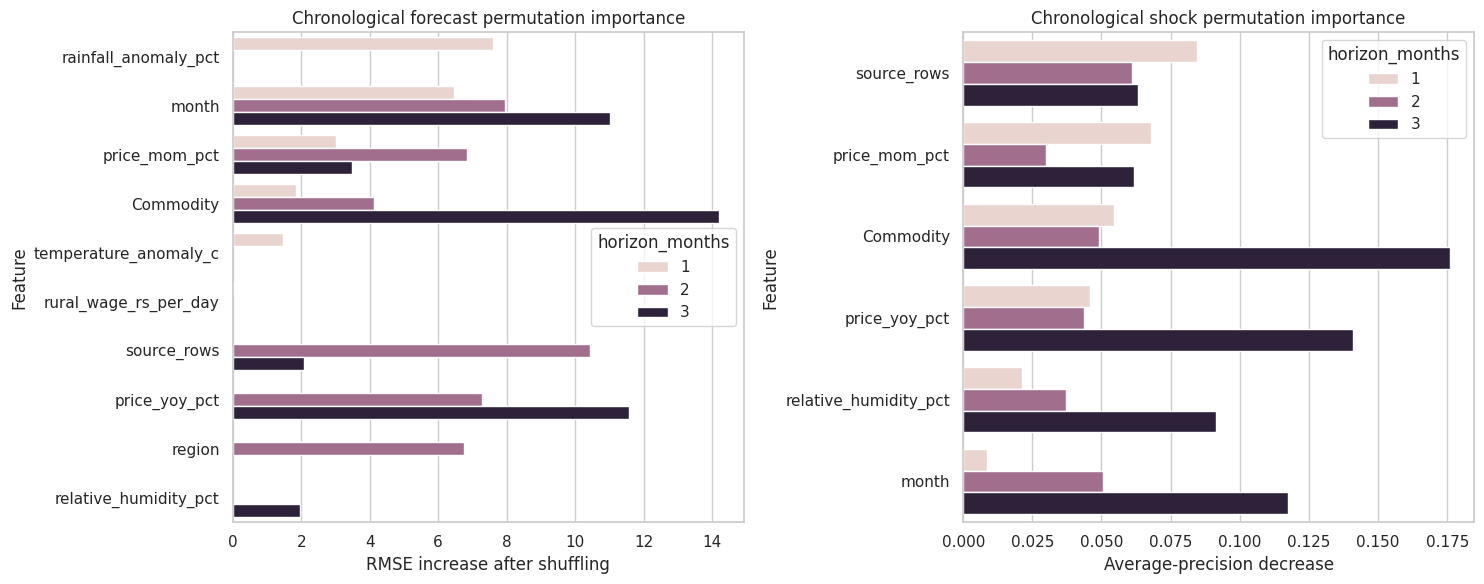

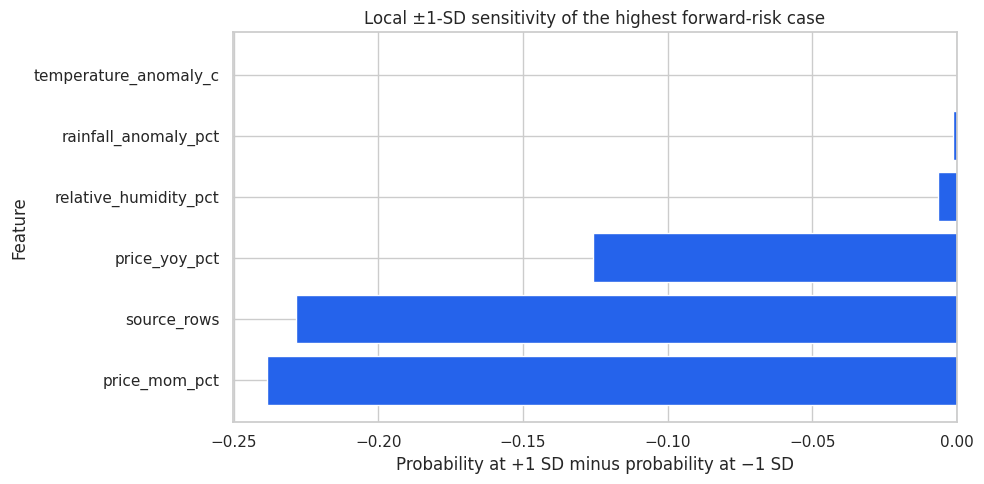

In [5]:
# Rank consistency across horizons distinguishes stable drivers from horizon-specific signals.
rank_table = (
    forecast_importance.assign(
        rank=lambda x: x.groupby("horizon_months")["rmse_increase_mean"].rank(ascending=False)
    )
    .pivot(index="feature", columns="horizon_months", values="rank")
)
rank_table["mean_rank"] = rank_table.mean(axis=1)
rank_table["rank_sd"] = rank_table.std(axis=1)
rank_table = rank_table.sort_values("mean_rank").reset_index()
rank_table.to_csv(REPORT_OUTPUT / "07_forecast_importance_rank_stability.csv", index=False)

if not SKIP_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fp = forecast_importance.groupby("horizon_months").head(6)
    sns.barplot(data=fp, x="rmse_increase_mean", y="feature", hue="horizon_months", ax=axes[0])
    axes[0].set(title="Chronological forecast permutation importance", xlabel="RMSE increase after shuffling", ylabel="Feature")
    sp = shock_importance.groupby("horizon_months").head(6)
    sns.barplot(data=sp, x="average_precision_decrease_mean", y="feature", hue="horizon_months", ax=axes[1])
    axes[1].set(title="Chronological shock permutation importance", xlabel="Average-precision decrease", ylabel="Feature")
    fig.tight_layout()
    fig.savefig(FIGURES / "07_aligned_global_explainability.png", bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    local_plot = local_sensitivity.head(10).sort_values("central_probability_change")
    colors = np.where(local_plot["central_probability_change"].ge(0), "#c2410c", "#2563eb")
    ax.barh(local_plot["feature"], local_plot["central_probability_change"], color=colors)
    ax.axvline(0, color="#374151", linewidth=0.8)
    ax.set(title="Local ±1-SD sensitivity of the highest forward-risk case",
           xlabel="Probability at +1 SD minus probability at −1 SD", ylabel="Feature")
    fig.tight_layout()
    fig.savefig(FIGURES / "07_highest_risk_local_sensitivity.png", bbox_inches="tight")
    plt.show()


## 6. Execution summary


In [6]:
top_forecast = forecast_importance.sort_values(
    ["horizon_months", "rmse_increase_mean"], ascending=[True, False]
).groupby("horizon_months").first().reset_index()
top_shock = shock_importance.sort_values(
    ["horizon_months", "average_precision_decrease_mean"], ascending=[True, False]
).groupby("horizon_months").first().reset_index()
summary = {
    "notebook": "07_explainability_synopsis_aligned",
    "status": "completed",
    "forecast_models_explained": nb05["selected_models_by_horizon"],
    "shock_models_explained": nb06["selected_models"],
    "top_forecast_features": {
        f"{int(row.horizon_months)}_month": row.feature for row in top_forecast.itertuples()
    },
    "top_shock_features": {
        f"{int(row.horizon_months)}_month": row.feature for row in top_shock.itertuples()
    },
    "highest_risk_case": {
        "target_date": str(pd.Timestamp(highest["target_date"]).date()),
        "horizon_months": horizon,
        "region": str(highest["region"]),
        "commodity": str(highest["Commodity"]),
        "reported_probability": float(highest["shock_probability"]),
        "refitted_probability": base_probability,
    },
    "leading_local_sensitivity_feature": str(local_sensitivity.iloc[0]["feature"]),
    "leading_local_probability_change": float(local_sensitivity.iloc[0]["central_probability_change"]),
    "importance_method": "chronological holdout permutation importance",
    "local_method": "one-standard-deviation central sensitivity",
    "interpretation": "Predictive importance and sensitivity; not causal attribution.",
    "output_root": str(OUTPUT_ROOT),
}
SUMMARY_FILE = REPORT_OUTPUT / "07_execution_summary.json"
SUMMARY_FILE.write_text(json.dumps(summary, indent=2), encoding="utf-8")
expected = [
    REPORT_OUTPUT / "07_forecast_permutation_importance.csv",
    REPORT_OUTPUT / "07_shock_permutation_importance.csv",
    REPORT_OUTPUT / "07_highest_risk_local_sensitivity.csv",
    REPORT_OUTPUT / "07_forecast_importance_rank_stability.csv",
    SUMMARY_FILE,
]
if not SKIP_PLOTS:
    expected += [
        FIGURES / "07_aligned_global_explainability.png",
        FIGURES / "07_highest_risk_local_sensitivity.png",
    ]
missing = [str(p) for p in expected if not p.exists()]
if missing: raise FileNotFoundError("\n".join(missing))
print("=" * 76)
print("NOTEBOOK 07 ALIGNED EXECUTION SUMMARY — PLEASE SHARE THIS OUTPUT")
print("=" * 76)
print(json.dumps(summary, indent=2))
print(f"\nVerified artifacts: {len(expected)}")


NOTEBOOK 07 ALIGNED EXECUTION SUMMARY — PLEASE SHARE THIS OUTPUT
{
  "notebook": "07_explainability_synopsis_aligned",
  "status": "completed",
  "forecast_models_explained": {
    "1_month": "hist_gradient_boosting",
    "2_month": "hist_gradient_boosting",
    "3_month": "hist_gradient_boosting"
  },
  "shock_models_explained": {
    "1_month": "hist_gradient_boosting",
    "2_month": "hist_gradient_boosting",
    "3_month": "hist_gradient_boosting"
  },
  "top_forecast_features": {
    "1_month": "rainfall_anomaly_pct",
    "2_month": "source_rows",
    "3_month": "Commodity"
  },
  "top_shock_features": {
    "1_month": "source_rows",
    "2_month": "source_rows",
    "3_month": "Commodity"
  },
  "highest_risk_case": {
    "target_date": "2026-10-01",
    "horizon_months": 3,
    "region": "Delhi",
    "commodity": "Rice",
    "reported_probability": 0.820457860788071,
    "refitted_probability": 0.8282022198447676
  },
  "leading_local_sensitivity_feature": "price_mom_pct",
  "le

## Notebook 07 conclusion

Permutation importance measures loss deterioration after a feature is shuffled;
local sensitivity measures how the fitted probability changes near one case.
Neither establishes a causal mechanism. Correlated predictors may share or
exchange importance, so results should be interpreted by variable group as well
as by individual rank.
